## Libraries

In [1]:
import sys
sys.path.append('../')
path = sys.path
datapath = str(path[-1:][0])+"../Datasets/"
results_folder = "./results/"
datapath

'../../Datasets/'

In [2]:
from silence_tensorflow import silence_tensorflow
silence_tensorflow()

import tensorflow as tf
import logging, os 
import numpy as np
from sklearn.utils import shuffle

import logging, os 
logging.disable(logging.WARNING) 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger('tensorflow').disabled = True

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [35]:
%load_ext autoreload
%autoreload 2

import re
import ast 

import time
import math
import random
import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path

from importlib import reload, import_module
reload(import_module("scripts.data_prep"))
reload(import_module("scripts.model"))
reload(import_module("scripts.results_analysis"))
from scripts.data_prep import *
from scripts.model import *
from scripts.results_analysis import *

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from torch.optim import Adam
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.utils.class_weight import compute_class_weight

from sklearn import datasets
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix)

import tensorflow as tf
from tensorflow import keras
from collections import Counter
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD
from  tensorflow.keras import Sequential, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation, Dense, Dropout

np.random.seed(1237)

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import torch
from torch import cuda
device = torch.device('cuda:1' if cuda.is_available() else 'cpu')

print(f"Current device: {device}")

Current device: cpu


### Inital Data Cleaning

In [5]:
## ## read the data
mddf = pd.read_csv(datapath+"datas20.csv")

######################################### 
## ## select only datas for which number of datapoints for a given label is about 40
counts = mddf["Labels"].value_counts(dropna=False)
ddf = mddf[mddf["Labels"].map(counts)>10].reset_index(drop=True)

## ## recompute the labels now that some are deleted
# Initialize the LabelEncoder
label_encoder = LabelEncoder()
ddf['old_labels'] = ddf['Labels'] 
ddf['Labels'] = label_encoder.fit_transform(ddf.Labels.values)

# ddf = mddf.copy()

In [6]:
datas = ddf.copy()

## ## convert the CFE and Samples to proper arrrays
datas['Sample'] = datas['Sample'].apply(convert_string_arr)
datas['Action_CFE'] = datas['Action_CFE'].apply(convert_string_arr)
datas['CFE'] = datas['CFE'].apply(convert_string_arr2)
datas['index'] = datas.index

In [7]:
## ## shuffle your dataset 
shuffle_df = datas.sample(frac=1, random_state=42)
## ## define a size for your train set 
train_size = int(0.8 * len(datas))
## ## split your dataset 
train_set = shuffle_df[:train_size]
test_set = shuffle_df[train_size:]

In [8]:
dat = train_set.copy(deep=False)
print("Number of data points with one action CFEs: ",len(dat[dat['CFE'].apply(lambda x: len(x)== 1)]))
print("Number of data points with two action CFEs: ", len(dat[dat['CFE'].apply(lambda x: len(x)== 2)]))
print("Number of data points with three action CFEs: ", len(dat[dat['CFE'].apply(lambda x: len(x)== 3)]))
print("Number of data points with four action CFEs: ", len(dat[dat['CFE'].apply(lambda x: len(x)== 4)]))

Number of data points with one action CFEs:  18804
Number of data points with two action CFEs:  34636
Number of data points with three action CFEs:  1665
Number of data points with four action CFEs:  0


### Data Preprocessing

In [9]:
def new_seq_labels(orig_y_target, orig_yts_target):
    
    unique_y = list(set(orig_y_target))
    unique_y.sort()
    unique_yts = list(set(orig_yts_target))
    unique_yts.sort()

    # max_len = max(len(unique_y), len(unique_yts))
    max_len = max(max(orig_y_target), max(orig_yts_target))+1

    y_hot_encod   = [[1 if i == j else 0 for i in range(max_len)] for j in orig_y_target]
    yts_hot_encod = [[1 if i == j else 0 for i in range(max_len)] for j in orig_yts_target]

    return np.asarray(y_hot_encod, dtype=np.int32), np.asarray(yts_hot_encod, dtype=np.int32), max_len

In [10]:
datas_samples_tr, train_target = train_set["Sample"], train_set["Labels"]
datas_samples_ts, test_target = test_set["Sample"], test_set["Labels"]

In [11]:
c = np.intersect1d(np.array(list(set(train_target))), np.array(list(set(test_target))))

len(c), len(list(set(train_target))), len(list(set(test_target)))

(600, 614, 600)

In [12]:
np.array(list(set(train_target).difference(list(set(test_target))))), np.array(list(set(test_target).difference(list(set(train_target)))))

(array([451, 583, 587, 591, 592, 531, 410, 476, 540, 606, 482, 427, 566,
        382]),
 array([], dtype=float64))

In [13]:
## ## create data for training
data_tr = pd.DataFrame([pd.Series(x) for x in datas_samples_tr])
data_tr.columns = ['feature_{}'.format(x+1) for x in data_tr.columns]

######
train_df = data_tr.copy(deep=False)
train_df.index = list(train_target.index)


## ## create data for testing
data_ts = pd.DataFrame([pd.Series(x) for x in datas_samples_ts])
data_ts.columns = ['feature_{}'.format(x+1) for x in data_ts.columns]

#####
test_df = data_ts.copy(deep=False)
test_df.index = list(test_target.index)


In [14]:
## ## remove column that has same value through-out
constant_cols = [c for c in train_df.columns if train_df[c].nunique() == 1]
###
train_df.drop(columns=constant_cols, inplace=True)
test_df.drop(columns=constant_cols, inplace=True)


## ##  feature-wise normalize the data: distribution with mean value 0 and standard deviation of 1
scaler = StandardScaler()
###
train_data = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns)
test_data = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns)


In [15]:
## ##
X = np.array([np.array(list(i)) for i in np.array(train_df)])
X_norm = np.array([np.array(list(i)) for i in np.array(train_data)])
y = np.array(list(train_target))


## ##
Xts = np.array([np.array(list(i)) for i in np.array(test_df)])
Xts_norm = np.array([np.array(list(i)) for i in np.array(test_data)])
yts = np.array(list(test_target))


## ##
input_size = X.shape[1]
output_size = 1
input_dim = X.shape[1]

## ## with this encoding, idx is equal to the label
## ##
y_hot, yts_hot, num_classes = new_seq_labels(y, yts)


In [16]:
num_classes

614

### Modelling

In [17]:
## ##
start = time.time()
## ##

## ## call and complile model
model = make_model1(input_dim, num_classes)
## 
model.compile(
    optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
)

## ## earl stop criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=350, restore_best_weights=True)

## ##train model
history = model.fit(X_norm, 
          y_hot,
          validation_split=0.03,
          epochs=3000,
          batch_size=800,
          callbacks=[early_stopping], 
          verbose=False)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(Xts_norm, yts_hot)
print(f'Test accuracy: {test_accuracy}')


print()
end = time.time()
print("Minutes it takes to run: ",round((end - start)/60, 3)) 

431/431 [==============================] - 2s 4ms/step - loss: 0.9133 - accuracy: 0.9842
Test accuracy: 0.9842491149902344

Minutes it takes to run:  64.617


In [18]:
## ## Evaluate the model

## ##
print()
test_loss, test_accuracy = model.evaluate(Xts_norm, yts_hot)
print(f'Test accuracy (from eval): {test_accuracy}')


## ##
y_pred_idx = np.argmax(model.predict(Xts_norm), axis=1)
## this is wrong as it takes the index as the value.
## While is true in most cases, it's not always true with how the data was coded with the automatic encoding 
## e.g in index 15, the label might actually 17. So while the model reports correctly the index, it fails 

accuracy_one = accuracy_score(yts, y_pred_idx)
f1_one = f1_score(yts, y_pred_idx, average='micro')
## 
print(f'Accuracy (use idx) : {accuracy_one}')
print(f'F1 Score (micro): {f1_one}')

## ##
##
y_pred_hot = [[1 if i == j else 0 for i in range(num_classes)] for j in y_pred_idx]
accuracy = accuracy_score(yts_hot, y_pred_hot)
f1 = f1_score(yts_hot, y_pred_hot, average='micro')

print()
print(f'Accuracy: {accuracy}')
print(f'F1 Score (micro): {f1}')


431/431 [==============================] - 2s 4ms/step - loss: 0.9133 - accuracy: 0.9842
Test accuracy (from eval): 0.9842491149902344
431/431 [==============================] - 1s 3ms/step
Accuracy (use idx) : 0.984249110836902
F1 Score (micro): 0.984249110836902

Accuracy: 0.984249110836902
F1 Score (micro): 0.984249110836902


### Results Evaluation

In [20]:
plot_model_res(results_folder+"nn_10_acts20_model.pdf", model, 100)

In [21]:
plot_model_non(results_folder+"nn_10_acts20_full_model.pdf", model, 100)

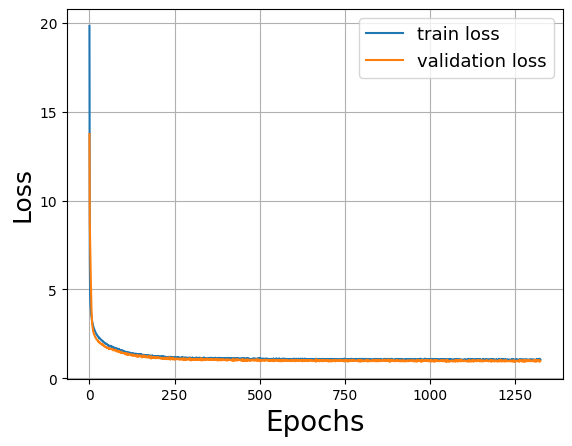

In [22]:
plot_result(history, "loss", results_folder+"nn_10_acts20_loss.pdf")

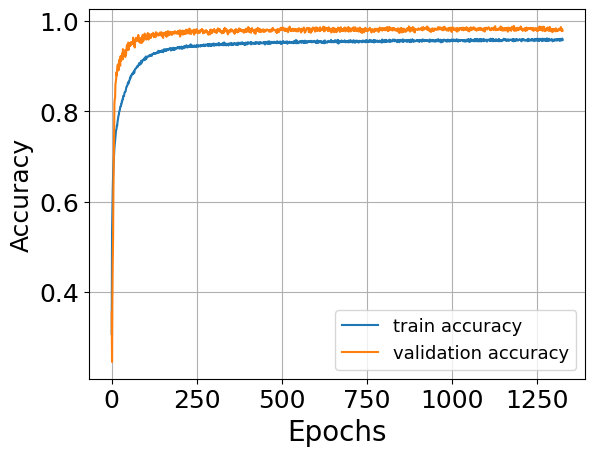

In [23]:
plot_result(history, "accuracy", results_folder+"nn_10_acts20_accuracy.pdf")

##### ``create action specific data``

In [24]:
ts_data = pd.DataFrame()
ts_data["Xtest"] = list(Xts_norm)
ts_data["ytest_hot"] = list(yts_hot)
ts_data["ytest"] = list(yts)
ts_data["CFE"] = list(test_set["CFE"])
ts_data["orig_idx"] = test_target.index
ts_data["curr_idx"]= ts_data.index
ts_data.head()

,Xtest,ytest_hot,ytest,CFE,orig_idx,curr_idx
0,"[0.7282251482047465, -1.3622133557997362, 0.74...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",102,"[[1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,...",41037,0
1,"[0.7282251482047465, -1.3622133557997362, 0.74...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",374,"[[1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,...",59118,1
2,"[0.7282251482047465, 0.7340993947404912, -1.34...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",290,"[[1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,...",9649,2
3,"[0.7282251482047465, 0.7340993947404912, 0.741...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",208,"[[0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,...",22099,3
4,"[0.7282251482047465, -1.3622133557997362, 0.74...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",483,"[[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,...",16259,4


In [25]:
one_acts = ts_data[ts_data['CFE'].apply(lambda x: len(x)== 1)]
two_acts = ts_data[ts_data['CFE'].apply(lambda x: len(x)== 2)]
three_acts = ts_data[ts_data['CFE'].apply(lambda x: len(x)== 3)]

##### ``analyze model results``

In [36]:

confidence_level = 0.95

stats_data = pd.DataFrame()
results_data = pd.DataFrame(columns=["Dataset", "Dataset size", "Loss", "Accuracy", 
                                         "Margin error", "Lower bound", "Upper bound"])

## ##
## ## whole dataset
print()
print("****************Whole dataset****************")
Xtest_acts = np.vstack(ts_data["Xtest"].to_numpy())
ytest_acts = np.vstack(ts_data.ytest_hot.to_numpy())

ds_pred =  np.argmax(model.predict(Xtest_acts), axis=1)
ds_y = ts_data.ytest.to_numpy()

wholeds, loss_h, acc_h, margin_of_error_h, lower_bound_h, upper_bound_h = get_nn_model_stats(y_ts = ds_y, 
                                                                            y_pred = ds_pred,
                                                                            conf_level = confidence_level,
                                                                            ts_size = len(ytest_acts))


results_data.loc[len(results_data.index)] = ['Full dataset', len(ytest_acts), loss_h, acc_h, 
                                                margin_of_error_h, lower_bound_h, upper_bound_h] 


## ##
## ## one action dataset
print()
print("****************One action dataset****************")
if len(one_acts) > 0:
    
    Xtest_act1 = np.vstack(one_acts["Xtest"].to_numpy()) 
    ytest_act1 = np.vstack(one_acts.ytest_hot.to_numpy())

    df1z_pred =  np.argmax(model.predict(Xtest_act1), axis=1)
    df1z_y = one_acts.ytest.to_numpy()
    
    gen_df1z, loss_h1z, acc_h1z, margin_of_error_h1z, lower_bound_h1z, upper_bound_h1z = get_nn_model_stats(y_ts = df1z_y, 
                                                                                            y_pred = df1z_pred,
                                                                                            conf_level = confidence_level,
                                                                                            ts_size = len(one_acts), 
                                                                                            num_acts = 1
                                                                                            )

    stats_data = pd.concat([stats_data, gen_df1z], axis=0).reset_index(drop=True)
    results_data.loc[len(results_data.index)] = ['One action dataset', len(ytest_act1), loss_h1z, acc_h1z, 
                                                margin_of_error_h1z, lower_bound_h1z, upper_bound_h1z] 
    
## ##
## ## two action dataset
print()
print("****************Two action dataset****************")
if len(two_acts) > 0:
    
    Xtest_act2 = np.vstack(two_acts["Xtest"].to_numpy()) 
    ytest_act2 = np.vstack(two_acts.ytest_hot.to_numpy()) 

    df2z_pred =  np.argmax(model.predict(Xtest_act2), axis=1)
    df2z_y = two_acts.ytest.to_numpy()
    
    gen_df2z, loss_h2z, acc_h2z, margin_of_error_h2z, lower_bound_h2z, upper_bound_h2z = get_nn_model_stats(y_ts = df2z_y, 
                                                                                            y_pred = df2z_pred,
                                                                                            conf_level = confidence_level,
                                                                                            ts_size = len(two_acts), 
                                                                                            num_acts = 2
                                                                                            )

    stats_data = pd.concat([stats_data, gen_df2z], axis=0).reset_index(drop=True)
    results_data.loc[len(results_data.index)] = ['Two action dataset', len(ytest_act2), loss_h2z,  acc_h2z, 
                                                margin_of_error_h2z, lower_bound_h2z, upper_bound_h2z] 
    
## ##
## ## three action dataset
print()
print("****************Three action dataset****************")
if len(three_acts) > 0:
    
    Xtest_act3 = np.vstack(three_acts["Xtest"].to_numpy()) 
    ytest_act3 = np.vstack(three_acts.ytest_hot.to_numpy())

    df3z_pred =  np.argmax(model.predict(Xtest_act3), axis=1)
    df3z_y = three_acts.ytest.to_numpy()
    
    gen_df3z, loss_h3z, acc_h3z, margin_of_error_h3z, lower_bound_h3z, upper_bound_h3z = get_nn_model_stats(y_ts = df3z_y, 
                                                                                            y_pred = df3z_pred,
                                                                                            conf_level = confidence_level,
                                                                                            ts_size = len(three_acts), 
                                                                                            num_acts = 3
                                                                                            )
 
    stats_data = pd.concat([stats_data, gen_df3z], axis=0).reset_index(drop=True)
    results_data.loc[len(results_data.index)] = ['Three action dataset', len(ytest_act3), loss_h3z,  acc_h3z, 
                                                margin_of_error_h3z, lower_bound_h3z, upper_bound_h3z] 


## ##
stats_data["zero_one"] = stats_data.apply(lambda x: 0 if x["errs"]==0 else 1, axis=1)
## ##
print()
plot_general_ds(stats_data, "one_two_three", results_folder+"nn_10_acts20_1n.pdf")
## ##
print()
plot_general(stats_data, "one_two_three", results_folder+"nn_10_acts20_1n1.pdf")


****************Whole dataset****************
431/431 [==============================] - 1s 3ms/step
Zero-One Loss: 1.5751
Estimated Accuracy: 98.4249
Confidence Level: 95.0%
Confidence Interval: (0.9822, 0.9863)
Estimated Accuracy: 98.4249 ± 0.0021 (95% CI: 0.9822 - 0.9863)

****************One action dataset****************
153/153 [==============================] - 0s 3ms/step
Zero-One Loss: 0.6571
Estimated Accuracy: 99.3429
Confidence Level: 95.0%
Confidence Interval: (0.9912, 0.9957)
Estimated Accuracy: 99.3429 ± 0.0023 (95% CI: 0.9912 - 0.9957)

****************Two action dataset****************
266/266 [==============================] - 1s 3ms/step
Zero-One Loss: 2.0351
Estimated Accuracy: 97.9649
Confidence Level: 95.0%
Confidence Interval: (0.9766, 0.9827)
Estimated Accuracy: 97.9649 ± 0.0030 (95% CI: 0.9766 - 0.9827)

****************Three action dataset****************
13/13 [==============================] - 0s 3ms/step
Zero-One Loss: 2.9557
Estimated Accuracy: 97.0443
Co

In [37]:
results_data

,Dataset,Dataset size,Loss,Accuracy,Margin error,Lower bound,Upper bound
0,Full dataset,13777,1.5751,98.4249,0.002079,0.982170,0.986328
1,One action dataset,4870,0.6571,99.3429,0.002269,0.991160,0.995698
2,Two action dataset,8501,2.0351,97.9649,0.003002,0.976647,0.982651
3,Three action dataset,406,2.9557,97.0443,0.016474,0.953969,0.986917


In [38]:
results_data.to_csv(results_folder+"nn_10_acts20.csv",  index=False)

## Analysing mistakes

### Part One

##### ``mistakes data prep``

In [39]:
### whole ds predictions
ds_pred


array([102, 374, 290, ...,  25,  25, 198])

In [40]:
### whole ds true target
ds_y

array([102, 374, 290, ...,  25,  25, 198])

In [41]:
### curated test set
test_set_sel = test_set[["Labels", "CFE_cost", "CFE", "Sample"]]

### add Label_pred, CFE_pred, CFE_cost_pred
test_set_sel["Label_pred"] = list(ds_pred)

## because of the imbalance, we use datas instead of the partions
test_set_sel["CFE_pred"] =  test_set_sel.apply(lambda x: np.array(datas[datas["Labels"]==int(x["Label_pred"])].iloc[0].CFE), axis=1)
test_set_sel["CFE_cost_pred"] =  test_set_sel.apply(lambda x: int(datas[datas["Labels"]==int(x["Label_pred"])].iloc[0].CFE_cost), axis=1)


##### ``feasibility of mistakes``

In [43]:
mistakes = test_set_sel[test_set_sel["Labels"] != test_set_sel["Label_pred"]]
mistakes['Sample_plus_pred'] = mistakes.apply(lambda x: x["Sample"]+np.sum(x["CFE_pred"], axis=0), axis=1)

feasible_mistakes = mistakes[mistakes['Sample_plus_pred'].apply(lambda x: len(list(np.where(x==0)[0]))==0)]
infeasible_mistakes = mistakes[mistakes['Sample_plus_pred'].apply(lambda x: len(list(np.where(x==0)[0]))>0)]

print(f'Number of mistakes: {len(mistakes)}')
print(f'Number of feasible mistakes: {len(feasible_mistakes)}')
print(f'Number of infeasible mistakes: {len(infeasible_mistakes)}')

if len(feasible_mistakes) > 0 and len(infeasible_mistakes) > 0:
    feasible_mistakes["num_mistakes"]  = feasible_mistakes.apply(lambda x: len(list(np.where(x['Sample_plus_pred']==0)[0])), axis=1)
    infeasible_mistakes["num_mistakes"]  = infeasible_mistakes.apply(lambda x: len(list(np.where(x['Sample_plus_pred']==0)[0])), axis=1)

Number of mistakes: 217
Number of feasible mistakes: 217
Number of infeasible mistakes: 0


##### ``feasible mistakes``

In [44]:
if len(feasible_mistakes) > 0:
    violin_plot(df_main=feasible_mistakes, 
                fig_size=(12,9), 
                save_as=results_folder+"nn_10_acts20_violin_feasible.pdf")

    box_plot(df_main=feasible_mistakes, 
                fig_size=(12,9), 
                save_as=results_folder+"nn_10_acts20_boxplot_feasible.pdf")

    percentiles_plot(df_main=feasible_mistakes, 
                    fig_size=(12,9), 
                    save_as=results_folder+"nn_10_acts20_percent_feasible.pdf")

##### ``infeasible mistakes``

In [45]:
if len(infeasible_mistakes) > 0:
    violin_plot(df_main=infeasible_mistakes, 
                fig_size=(12,9), 
                save_as=results_folder+"nn_10_acts20_violin_infeasible.pdf")

    box_plot(df_main=infeasible_mistakes, 
                fig_size=(12,9), 
                save_as=results_folder+"nn_10_acts20_boxplot_infeasible.pdf")

    percentiles_plot(df_main=infeasible_mistakes, 
                    fig_size=(12,9), 
                    save_as=results_folder+"nn_10_acts20_percent_infeasible.pdf")

### Part Two

In [47]:
init_datas_samples_tr, init_train_target = train_set["Sample"], train_set["Labels"]
init_datas_samples_ts, init_test_target = test_set["Sample"], test_set["Labels"]

In [48]:
ts_less_20 = np.array(list(dict((k, v) for k, v in dict(Counter(list(init_train_target.to_numpy()))).items() if v <= 20).keys()))

In [49]:
if len(feasible_mistakes) > 0:
    feasible_less_20 = feasible_mistakes[feasible_mistakes["Labels"].isin(list(ts_less_20))]
    print("Num feasible mistakes: ", len(feasible_mistakes))
    print("Size less than 20: ", len(feasible_less_20))
    print("Percentage  of those: ", round((len(feasible_less_20)/len(feasible_mistakes))*100, 3))
    if len(feasible_less_20) > 0:
        violin_plot(df_main=feasible_less_20, 
                    fig_size=(12,9), 
                    save_as=results_folder+"nn_10_acts20_violin_feasible_less20.pdf")

        box_plot(df_main=feasible_less_20, 
                    fig_size=(12,9), 
                    save_as=results_folder+"nn_10_acts20_boxplot_feasible_less20.pdf")

        percentiles_plot(df_main=feasible_less_20, 
                        fig_size=(12,9), 
                        save_as=results_folder+"nn_10_acts20_percent_feasible_less20.pdf")

Num feasible mistakes:  217
Size less than 20:  55
Percentage  of those:  25.346


In [50]:
if len(infeasible_mistakes) > 0:
    infeasible_less_20 = infeasible_mistakes[infeasible_mistakes["Labels"].isin(list(ts_less_20))]
    print("Num infeasible mistakes: ", len(infeasible_mistakes))
    print("Size less than 20: ", len(infeasible_less_20))
    print("Percentage  of those: ", round((len(infeasible_less_20)/len(infeasible_mistakes))*100, 3))
    if len(infeasible_less_20) > 0:
        violin_plot(df_main=infeasible_less_20, 
                    fig_size=(12,9), 
                    save_as=results_folder+"nn_10_acts20_violin_infeasible_less20.pdf")

        box_plot(df_main=infeasible_less_20, 
                    fig_size=(12,9), 
                    save_as=results_folder+"nn_10_acts20_boxplot_infeasible_less20.pdf")

        percentiles_plot(df_main=infeasible_less_20, 
                        fig_size=(12,9), 
                        save_as=results_folder+"nn_10_acts20_percent_infeasible_less20.pdf")

In [51]:
if len(ts_less_20) > 0:
    print(round((len(mistakes)/len(test_set[test_set["Labels"].isin(list(ts_less_20))]))*100, 3))

37.414


In [52]:
if len(ts_less_20) > 0:
    n_inf_less = len(infeasible_less_20)
    n_feas_less = len(feasible_less_20)
    n_inf = len(infeasible_mistakes)
    n_feas = len(feasible_mistakes)
    print("percentage of mistakes that are of less than 20 frequency: ",round(((n_inf_less+n_feas_less)/(n_inf+n_feas))*100, 3))
    print("percentage of feasible mistakes that are of less than 20 frequency: ",round((n_feas_less/n_feas)*100, 3))
    print("percentage of infeasible mistakes that are of less than 20 frequency: ",round((n_inf_less/n_inf)*100, 3))

NameError: name 'infeasible_less_20' is not defined